In [1]:
library(ggplot2)
library(dplyr)
library(data.table)
library(ggrepel)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last




In [ ]:
# CNN-Prediction


dir <- '/machineLearningForComputationalBiology/Cortex_Cell-TACIT/data/tidy_data/240_predictions_matrix_species/Human/'

# per-celltype subdirs (drop the parent dir itself)
celltype_dirs  <- list.dirs(dir, recursive = FALSE, full.names = TRUE)
celltype_dirs  <- celltype_dirs[!celltype_dirs %like% 'L3.5.IT|L4.IT']
celltype_names <- basename(celltype_dirs)

LQ0 <- read.csv('/home/dschaffe/enhancer-clustering/data/teeling_longevity_2-12-21.csv')

human_col <- "Homo_sapiens"   # <-- set to whatever the human column is actually named

results <- data.frame()

for (i in seq_along(celltype_dirs)) {
    cdir <- celltype_dirs[i]
    print(basename(cdir))

    names <- unlist(read.table(file.path(cdir, '240_predictions_NamesList.txt')))
    mtx   <- read.table(file.path(cdir, '240_predictions_Matrix.tsv'),
                        sep = '\t', row.names = 1)
    colnames(mtx) <- names

    LQ  <- LQ0
    mtx <- mtx[, colnames(mtx) %in% LQ$animal]
    mtx <- mtx[rownames(mtx) %like% 'hg38', ]
    mtx[mtx == -1] <- NA

    LQ  <- LQ[LQ$animal %in% colnames(mtx), ]
    LQ  <- LQ[LQ$order == 'Primates', ]
    LQ  <- LQ[order(LQ$LQ), ]
    mtx <- mtx[, match(LQ$animal, names(mtx))]

    # --- pick peak(s) with highest (human - best other species) difference ---
    if (!human_col %in% colnames(mtx)) {
        warning(sprintf("'%s' not found for %s; skipping", human_col, celltype_names[i]))
        next
    }

    other     <- setdiff(colnames(mtx), human_col)
    other_mtx <- as.matrix(mtx[, other, drop = FALSE])

    max_other_val <- apply(other_mtx, 1, function(x)
        if (all(is.na(x))) NA_real_ else max(x, na.rm = TRUE))
    max_other_sp  <- apply(other_mtx, 1, function(x)
        if (all(is.na(x))) NA_character_ else other[which.max(x)])

    human_val <- mtx[[human_col]]
    diff      <- human_val - max_other_val

    if (all(is.na(diff))) next

    # all peaks tied for the maximum difference (not just the first)
    best <- which(diff == max(diff, na.rm = TRUE))

    results <- rbind(results, data.frame(
        celltype         = celltype_names[i],
        peak             = rownames(mtx)[best],
        human_val        = human_val[best],
        best_species     = max_other_sp[best],
        best_species_val = max_other_val[best],
        difference       = diff[best],
        n_tied           = length(best),
        stringsAsFactors = FALSE
    ))
}

results <- results[order(results$difference, decreasing = T),]
results

In [45]:
# CNN-Prediction for a specific peak 


dir <- '/machineLearningForComputationalBiology/Cortex_Cell-TACIT/data/tidy_data/240_predictions_matrix_species/Human/'

# per-celltype subdirs (drop the parent dir itself)
celltype_dirs  <- list.dirs(dir, recursive = FALSE, full.names = TRUE)
celltype_dirs  <- celltype_dirs[!celltype_dirs %like% 'L3.5.IT|L4.IT']
celltype_names <- basename(celltype_dirs)

LQ0 <- read.csv('/home/dschaffe/enhancer-clustering/data/teeling_longevity_2-12-21.csv')

peak <- 'hg38:chr12:6284924-6285425'
result_list <- list()

for (i in seq_along(celltype_dirs)) {
    cdir <- celltype_dirs[i]
    ct   <- basename(cdir)
    message(ct)

    names <- unlist(read.table(file.path(cdir, '240_predictions_NamesList.txt')))
    mtx   <- read.table(file.path(cdir, '240_predictions_Matrix.tsv'),
                        sep = '\t', row.names = 1)
    colnames(mtx) <- names

    if (!(peak %in% rownames(mtx))) next        # skip cell types lacking the peak

    LQ  <- LQ0
    mtx <- mtx[, colnames(mtx) %in% LQ$animal, drop = FALSE]
    mtx <- mtx[rownames(mtx) %in% peak, , drop = FALSE]
    mtx[mtx == -1] <- NA
    LQ  <- LQ[LQ$animal %in% colnames(mtx), ]
    LQ  <- LQ[order(LQ$LQ), ]
    mtx <- mtx[, match(LQ$animal, names(mtx)), drop = FALSE]

    result_list[[ct]] <- data.frame(
        celltype = ct,
        animal   = colnames(mtx),
        value    = as.numeric(unlist(mtx[1, ])),
        LQ       = LQ$LQ,                        # aligned: cols reordered to LQ order
        stringsAsFactors = FALSE
    )
}

stacked <- do.call(rbind, result_list)
rownames(stacked) <- NULL


Astro

Endo

L2.3.IT

L3.4.IT

L4.5.IT

L5.6.IT.Car3

L5.6.NP

L5.ET

L5.IT

L6.CT

L6.IT

L6b

LAMP5

Microglia

Oligo

Opc

PAX6

PVALB

SST

VIP

VLMC



In [79]:
LQ0 <- read.csv('/home/dschaffe/enhancer-clustering/data/teeling_longevity_2-12-21.csv')
LQ1 <- LQ0[,c('order','animal','l.long')]
df <- left_join(stacked, LQ1, by='animal')
#df <- df[df$order %in% 'Primates',]

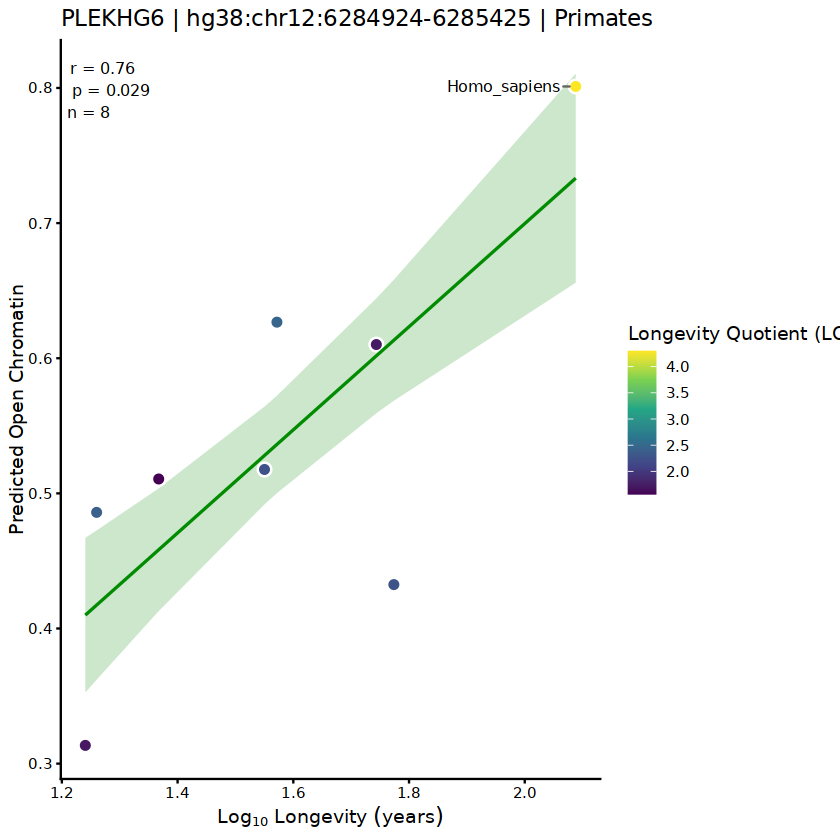

In [75]:
# Manuscript Supp Figure 2 --------------------------------------------------------
#----------------------------------------------------------------------------------

# ---- Columns ----
animal_col    <- 'animal'
longevity_col <- 'l.long'   # log10 longevity          -> predictor (x)
lq_col        <- 'LQ'       # longevity quotient       -> point fill
pred_col      <- 'value'    # predicted open chromatin -> response (y)

human <- 'Homo_sapiens'     # adjust to match your data; see check below

# ---- Prepare data ----
d <- df[complete.cases(df[, c(pred_col, longevity_col, lq_col)]), ]

# Sanity check on the human label — fails quietly otherwise
h <- d[d[[animal_col]] == human, ]
if (nrow(h) == 0) {
  warning('No row matched "', human, '". Candidates: ',
          paste(grep('sapiens|homo|hg38', d[[animal_col]],
                     ignore.case = TRUE, value = TRUE), collapse = ', '))
}

# ---- Fit: chromatin ~ longevity ----
fit <- lm(d[[pred_col]] ~ d[[longevity_col]])
s   <- summary(fit)
n   <- nrow(d)
r   <- sign(coef(fit)[2]) * sqrt(s$r.squared)
p   <- coef(s)[2, 4]

# Fitted values + SE of the fitted mean
pr    <- predict(fit, se.fit = TRUE)
d$fit <- pr$fit
d$se  <- pr$se.fit
# For a 95% CI instead of ±1 SE:
# d$se <- qt(0.975, df = n - 2) * pr$se.fit

# Sort so the ribbon draws cleanly; re-subset human after sorting
d <- d[order(d[[longevity_col]]), ]
h <- d[d[[animal_col]] == human, ]

# ---- Plot ----
ggplot(d, aes(x = .data[[longevity_col]], y = .data[[pred_col]])) +
  geom_ribbon(aes(ymin = fit - se, ymax = fit + se),
              fill = 'green4', alpha = 0.2) +
  geom_point(aes(fill = .data[[lq_col]]),
             shape = 21, size = 3, color = 'white', stroke = 0.8) +
  geom_text_repel(data = h, aes(label = .data[[animal_col]]),
                  size = 3.2, fontface = 'italic',
                  box.padding = 0.6, point.padding = 0.4,
                  min.segment.length = 0, segment.color = 'grey40') +
  geom_line(aes(y = fit), color = 'green4', linewidth = 0.7) +
  annotate('text', x = -Inf, y = Inf, hjust = -0.15, vjust = 1.4, size = 3.2,
           label = sprintf('r = %.2f\np = %.2g\nn = %d', r, p, n)) +
  scale_fill_viridis_c(name = 'Longevity Quotient (LQ)') +
  labs(title='PLEKHG6 | hg38:chr12:6284924-6285425 | Primates',
      x = expression(Log[10]~Longevity~(years)),
       y = 'Predicted Open Chromatin') +
  theme_classic(base_size = 11)

ggsave(paste0(PLOTDIR,'/Longevity_vs_Chromatin_LQ_primates.pdf'),
       width = 6, height = 4, dpi = 300)

In [15]:
# CNN-Prediction + phyloLM results 

library(data.table)

dir     <- '/machineLearningForComputationalBiology/Cortex_Cell-TACIT/data/tidy_data/240_predictions_matrix_species/Human/'
out_dir <- '/Aging/LQ_TACIT/phylolm/'   # <-- set this to wherever the per-celltype phylolm_r0_s1_bh_corrected.csv files live

celltype_dirs  <- list.dirs(dir, recursive = FALSE, full.names = TRUE)
celltype_dirs  <- celltype_dirs[!celltype_dirs %like% 'L3.5.IT|L4.IT']
celltype_names <- basename(celltype_dirs)

LQ0 <- read.csv('/home/dschaffe/enhancer-clustering/data/teeling_longevity_2-12-21.csv')
human_col <- "Homo_sapiens"
top_n <- 100

results <- data.frame()

for (i in seq_along(celltype_dirs)) {
    cdir  <- celltype_dirs[i]
    cname <- celltype_names[i]
    print(cname)

    # --- 1. load phylolm results, get top 5 most positively associated peaks ---
    bh_file <- file.path(out_dir, cname, 'phylolm_r0_s1_bh_corrected.csv')
    if (!file.exists(bh_file)) {
        warning(sprintf("phylolm file missing for %s; skipping", cname))
        next
    }
    # assumes peak IDs are in the first column / rownames -- adjust if there's
    # a named column like 'peak' instead
    bh <- read.csv(bh_file, row.names = 1)

    bh <- bh[rownames(bh) %like% 'hg38',]
    bh_ocr     <- bh[bh$bh < 0.05, ]
    bh_ocr_pos <- bh_ocr[bh_ocr$Coeff > 0, ]
    if (nrow(bh_ocr_pos) == 0) {
        warning(sprintf("no significant positive peaks for %s", cname))
        next
    }
    bh_ocr_pos <- bh_ocr_pos[order(-bh_ocr_pos$Coeff), ]
    #bh_ocr_pos <- bh_ocr_pos[order(bh_ocr_pos$bh), ]
    top_peaks  <- rownames(bh_ocr_pos)[seq_len(min(top_n, nrow(bh_ocr_pos)))]

    # --- 2. load prediction matrix, restrict to those peaks ---
    names <- unlist(read.table(file.path(cdir, '240_predictions_NamesList.txt')))
    mtx   <- read.table(file.path(cdir, '240_predictions_Matrix.tsv'),
                        sep = '\t', row.names = 1)
    colnames(mtx) <- names

    LQ  <- LQ0
    mtx <- mtx[, colnames(mtx) %in% LQ$animal]
    mtx[mtx == -1] <- NA
    LQ  <- LQ[LQ$animal %in% colnames(mtx), ]
    LQ  <- LQ[LQ$order == 'Primates', ]
    LQ  <- LQ[order(LQ$LQ), ]
    mtx <- mtx[, match(LQ$animal, names(mtx))]

    if (!human_col %in% colnames(mtx)) {
        warning(sprintf("'%s' not found for %s; skipping", human_col, cname))
        next
    }

    top_peaks_present <- intersect(top_peaks, rownames(mtx))
    if (length(top_peaks_present) == 0) {
        warning(sprintf("none of top peaks found in prediction matrix for %s", cname))
        next
    }
    mtx_sub <- mtx[top_peaks_present, , drop = FALSE]

    other     <- setdiff(colnames(mtx_sub), human_col)
    other_mtx <- as.matrix(mtx_sub[, other, drop = FALSE])
    max_other_val <- apply(other_mtx, 1, function(x)
        if (all(is.na(x))) NA_real_ else max(x, na.rm = TRUE))
    max_other_sp  <- apply(other_mtx, 1, function(x)
        if (all(is.na(x))) NA_character_ else other[which.max(x)])

    human_val <- mtx_sub[[human_col]]
    diff      <- human_val - max_other_val

    results <- rbind(results, data.frame(
        celltype         = cname,
        peak             = top_peaks_present,
        Coeff            = bh_ocr_pos$Coeff[match(top_peaks_present, rownames(bh_ocr_pos))],
        bh               = bh_ocr_pos$bh[match(top_peaks_present, rownames(bh_ocr_pos))],
        human_val        = human_val,
        best_species     = max_other_sp,
        best_species_val = max_other_val,
        difference       = diff,
        stringsAsFactors = FALSE
    ))
}

results <- results[order(results$difference, decreasing = TRUE), ]
results

[1] "Astro"
[1] "Endo"
[1] "L2.3.IT"
[1] "L3.4.IT"


Warning message:
“phylolm file missing for L3.4.IT; skipping”


[1] "L4.5.IT"
[1] "L5.6.IT.Car3"
[1] "L5.6.NP"
[1] "L5.ET"
[1] "L5.IT"


Warning message:
“phylolm file missing for L5.IT; skipping”


[1] "L6.CT"
[1] "L6.IT"
[1] "L6b"


Warning message:
“phylolm file missing for L6b; skipping”


[1] "LAMP5"
[1] "Microglia"
[1] "Oligo"
[1] "Opc"
[1] "PAX6"
[1] "PVALB"
[1] "SST"
[1] "VIP"
[1] "VLMC"


Warning message:
“no significant positive peaks for VLMC”


,celltype,peak,Coeff,bh,human_val,best_species,best_species_val,difference
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
hg38:chr12:6284924-6285425,Microglia,hg38:chr12:6284924-6285425,2.8684578,3.458489e-04,0.801096,Lemur_catta,0.626697,0.174399
hg38:chr7:149497479-149497980,Oligo,hg38:chr7:149497479-149497980,2.0555037,1.811118e-03,0.838542,Callicebus_donacophilus,0.691984,0.146558
hg38:chr3:188153894-188154395,Opc,hg38:chr3:188153894-188154395,1.8762488,6.900230e-04,0.900400,Mirza_coquereli,0.767504,0.132896
hg38:chr1:116426356-116426857,Oligo,hg38:chr1:116426356-116426857,2.1433990,9.044840e-03,0.819114,Eulemur_fulvus,0.688937,0.130177
hg38:chr22:42614388-42614889,Microglia,hg38:chr22:42614388-42614889,2.0016548,7.386888e-03,0.866651,Cebus_capucinus,0.743319,0.123332
hg38:chr15:98428314-98428815,Opc,hg38:chr15:98428314-98428815,1.8429632,7.682460e-05,0.861668,Ateles_geoffroyi,0.746464,0.115204
hg38:chr16:47371562-47372063,Oligo,hg38:chr16:47371562-47372063,1.9490555,4.919589e-03,0.793658,Colobus_angolensis,0.687030,0.106628
hg38:chr13:20526197-20526698,Microglia,hg38:chr13:20526197-20526698,2.0368828,5.394236e-03,0.781843,Cebus_capucinus,0.680358,0.101485
hg38:chr15:75802003-75802504,Opc,hg38:chr15:75802003-75802504,1.9798292,7.554771e-03,0.850553,Lemur_catta,0.750794,0.099759


In [18]:
# Generate bed file

results <- results[results$difference > 0,]
coords <- results$peak                     # e.g. "hg38:chr4:651409-651910"
parts <- do.call(rbind, strsplit(coords, "[:-]"))  # splits on : and -
# parts[,1] = "hg38", parts[,2] = "chr4", parts[,3] = "651409", parts[,4] = "651910"

bed <- data.frame(
    chrom = parts[, 2],
    start = as.integer(parts[, 3]) - 1L,   # BED is 0-based, half-open
    end   = as.integer(parts[, 4]),
    name  = results$peak,
    score = results$difference,
    stringsAsFactors = FALSE
)

bed
write.table(bed, "/Aging/LQ_TACIT/data/tables/human_nhp_peaks_phylolm.bed",
            sep = "\t", quote = FALSE,
            row.names = FALSE, col.names = FALSE) 

chrom,start,end,name,score
<chr>,<int>,<int>,<chr>,<dbl>
chr12,6284923,6285425,hg38:chr12:6284924-6285425,0.174399
chr7,149497478,149497980,hg38:chr7:149497479-149497980,0.146558
chr3,188153893,188154395,hg38:chr3:188153894-188154395,0.132896
chr1,116426355,116426857,hg38:chr1:116426356-116426857,0.130177
chr22,42614387,42614889,hg38:chr22:42614388-42614889,0.123332
chr15,98428313,98428815,hg38:chr15:98428314-98428815,0.115204
chr16,47371561,47372063,hg38:chr16:47371562-47372063,0.106628
chr13,20526196,20526698,hg38:chr13:20526197-20526698,0.101485
chr15,75802002,75802504,hg38:chr15:75802003-75802504,0.099759


In [21]:
# Peak Annotation (using bedtools)

anno = read.table('/Aging/LQ_TACIT/data/tables/human_nhp_peaks_phylolm_peakAnno_hg38.tsv')[c(1,3)]
colnames(anno) = c('peak','nearest_gene')

results = left_join(results, anno, by='peak')

write.csv(results,'/Aging/LQ_TACIT/data/tables//results_human_nhp_peaks_phylolm_peakAnno_hg38.tsv')
#results <- read.csv('/Aging/LQ_TACIT/data/tables//results_human_nhp_peaks_peakAnno_hg38.tsv')

results

celltype,peak,Coeff,bh,human_val,best_species,best_species_val,difference,nearest_gene
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
Microglia,hg38:chr12:6284924-6285425,2.8684578,3.458489e-04,0.801096,Lemur_catta,0.626697,0.174399,PLEKHG6
Oligo,hg38:chr7:149497479-149497980,2.0555037,1.811118e-03,0.838542,Callicebus_donacophilus,0.691984,0.146558,ZNF746
Opc,hg38:chr3:188153894-188154395,1.8762488,6.900230e-04,0.900400,Mirza_coquereli,0.767504,0.132896,LPP-AS2
Oligo,hg38:chr1:116426356-116426857,2.1433990,9.044840e-03,0.819114,Eulemur_fulvus,0.688937,0.130177,ATP1A1-AS1
Microglia,hg38:chr22:42614388-42614889,2.0016548,7.386888e-03,0.866651,Cebus_capucinus,0.743319,0.123332,RNU12
Opc,hg38:chr15:98428314-98428815,1.8429632,7.682460e-05,0.861668,Ateles_geoffroyi,0.746464,0.115204,LINC02351
Oligo,hg38:chr16:47371562-47372063,1.9490555,4.919589e-03,0.793658,Colobus_angolensis,0.687030,0.106628,LOC101927080
Microglia,hg38:chr13:20526197-20526698,2.0368828,5.394236e-03,0.781843,Cebus_capucinus,0.680358,0.101485,CRYL1
Opc,hg38:chr15:75802003-75802504,1.9798292,7.554771e-03,0.850553,Lemur_catta,0.750794,0.099759,GOLGA6EP


In [19]:
PLOTDIR="/Aging/LQ_TACIT/plots/VGP/"

cell_types <- c(
  'L2.3.IT','L3.4.IT','L4.5.IT',
  'L5.ET','L5.IT',
    'L5.6.IT.Car3','L5.6.NP',
    'L6.CT','L6.IT','L6b',
  'LAMP5','PAX6','PVALB','SST','VIP',
  'Astro','Microglia','Oligo','Opc','Endo'
)

plot_df <- results %>%
  group_by(celltype) %>%
  arrange(desc(difference), .by_group = TRUE) %>%
  slice(1) %>%
  ungroup() %>%
  filter(celltype %in% cell_types) %>%
  mutate(
    celltype = factor(celltype, levels = rev(cell_types)),
    label    = ifelse(is.na(nearest_gene2), peak,
                      paste0(nearest_gene2, "  |  ", peak))
  )

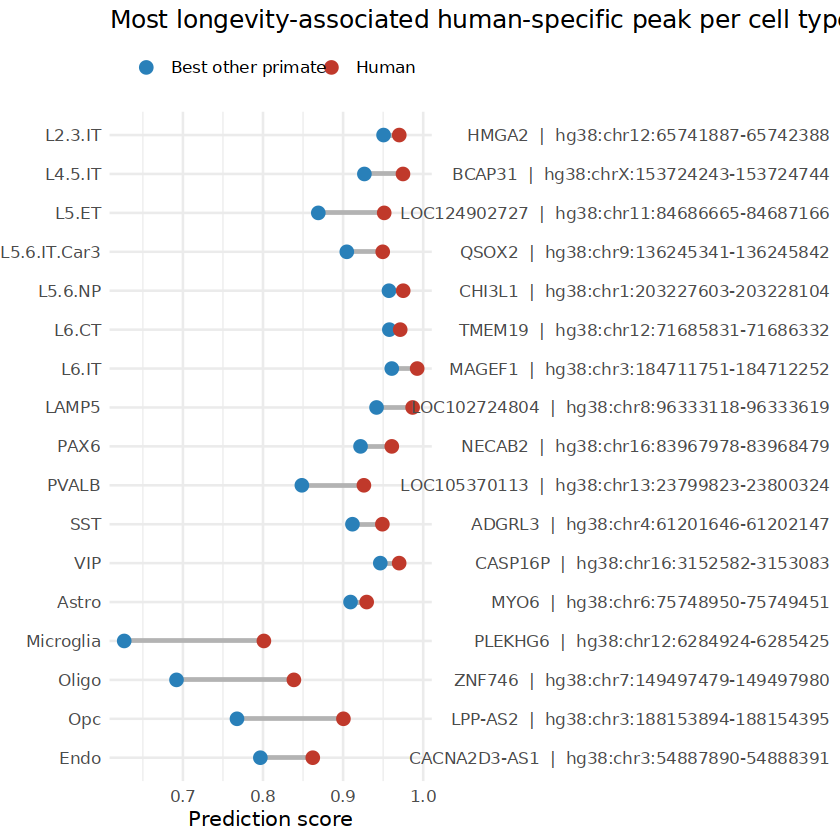

In [18]:
# Manuscript Supp Figure 2 --------------------------------------------------------
#----------------------------------------------------------------------------------

present_celltypes <- cell_types[cell_types %in% plot_df$celltype]

plot_df <- plot_df %>%
  mutate(celltype = factor(celltype, levels = rev(present_celltypes)))

lab_lookup <- setNames(plot_df$label, as.character(plot_df$celltype))
right_labs <- lab_lookup[levels(plot_df$celltype)]

p <- ggplot(plot_df) +
  geom_segment(aes(x = best_species_val, xend = human_val,
                   y = celltype, yend = celltype),
               color = "grey70", linewidth = 1) +
  geom_point(aes(x = best_species_val, y = celltype, color = "Best other primate"), size = 3) +
  geom_point(aes(x = human_val,        y = celltype, color = "Human"),              size = 3) +
  scale_color_manual(values = c("Human" = "#c0392b", "Best other primate" = "#2980b9"),
                     name = NULL) +
  scale_y_discrete(sec.axis = dup_axis(labels = right_labs, name = NULL)) +
  labs(x = "Prediction score", y = NULL,
       title = "Most longevity-associated human-specific peak per cell type") +
  theme_minimal(base_size = 12) +
  theme(legend.position = "top")
p

#ggsave(
#   filename = paste0(PLOTDIR, "human_nhp_peak_phylolm_dbplt.pdf"),
#   plot     = p,
#   width    = 7,
#   height   = 7,
#   device   = cairo_pdf
# )